# Markov Regime Model Demo

This notebook demonstrates a Hidden Markov Model workflow for detecting latent market regimes. The goal is to show how an observed return series can be explained by unobserved states such as defensive, stressed, and growth regimes.

The data is synthetic and seeded so the notebook runs offline and does not depend on external market data or any reference images.

In [25]:
from riskoptima import RiskOptima
print(RiskOptima.VERSION)

2.4.1


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from riskoptima.reporting import (
    build_markov_regime_report,
    plot_markov_regime_chart,
    plot_markov_regime_probabilities,
)

plt.style.use("seaborn-v0_8-whitegrid")

## 1. Create a return series with latent regimes

A Hidden Markov Model assumes that we observe returns, volatility, or another market feature, but the actual market state is hidden. Here we generate three segments with different drift and volatility so the model has a clear pattern to learn.

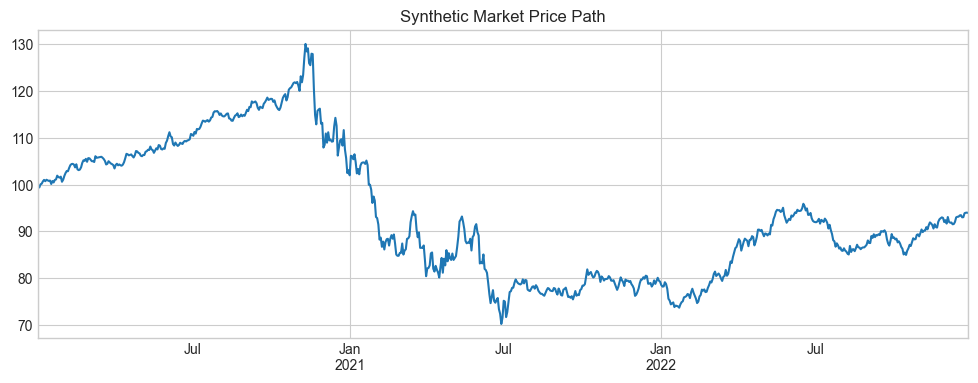

In [4]:
rng = np.random.default_rng(123)
dates = pd.bdate_range("2020-01-02", periods=780)

defensive = rng.normal(0.00035, 0.005, size=220)
stress = rng.normal(-0.00130, 0.020, size=180)
recovery = rng.normal(0.00095, 0.009, size=220)
sideways = rng.normal(0.00005, 0.007, size=160)

returns = pd.Series(
    np.r_[defensive, stress, recovery, sideways],
    index=dates,
    name="synthetic_market_returns",
)
prices = (1.0 + returns).cumprod() * 100.0
prices.plot(title="Synthetic Market Price Path", figsize=(12, 4));

## 2. Fit the Gaussian HMM report

RiskOptima fits a compact univariate Gaussian HMM. Regimes are sorted by fitted mean from weakest to strongest, which makes the labels stable across runs.

In [6]:
report = build_markov_regime_report(
    prices,
    input_type="prices",
    n_regimes=3,
    random_state=42,
    n_iter=100,
)

report.metrics["transition_matrix"].round(3)

,Regime 0,Regime 1,Regime 2
Regime 0,0.676,0.000,0.324
Regime 1,0.000,0.998,0.002
Regime 2,0.771,0.021,0.208


## 3. Inspect regime-level statistics

The summary table shows how each hidden state behaves in return space. A practical workflow would use these statistics to label states as bear/stress, neutral, or bull/recovery.

In [8]:
report.metrics["regime_summary"].round(5)

,count,mean,std,min,max
regime,,,,,
0,134,-0.00945,0.01962,-0.06727,0.05061
1,603,0.00067,0.00729,-0.02735,0.02274
2,42,0.02058,0.00738,0.00940,0.03925


## 4. Plot cumulative value colored by regime

This chart is the reusable RiskOptima version of a market-regime figure: the cumulative path is shown through time, and each point is colored by the most likely hidden state.

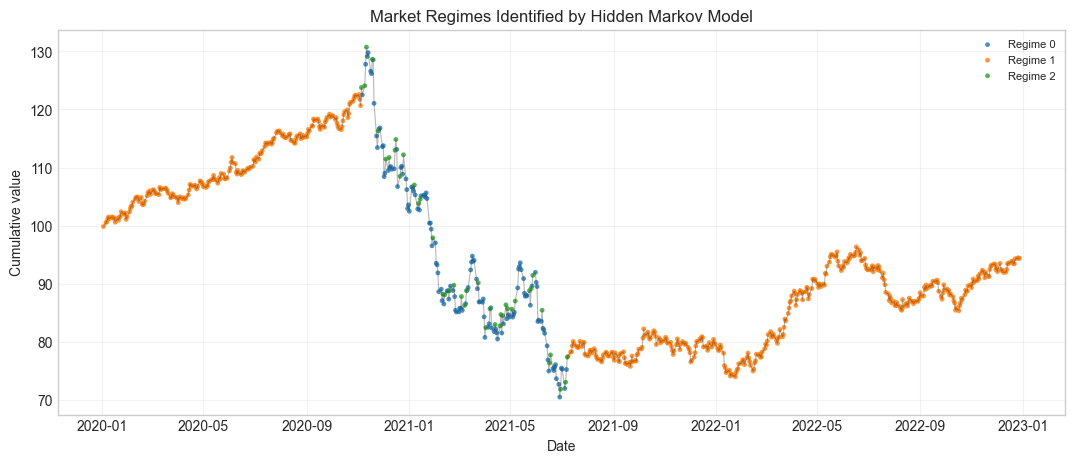

In [10]:
fig, ax = plt.subplots(figsize=(13, 5))
plot_markov_regime_chart(report, ax=ax)
plt.show()

## 5. Plot regime probabilities

The probability chart is useful for dashboards because it shows uncertainty. Regime changes are rarely perfectly crisp; probability drift can be more informative than the hard state label alone.

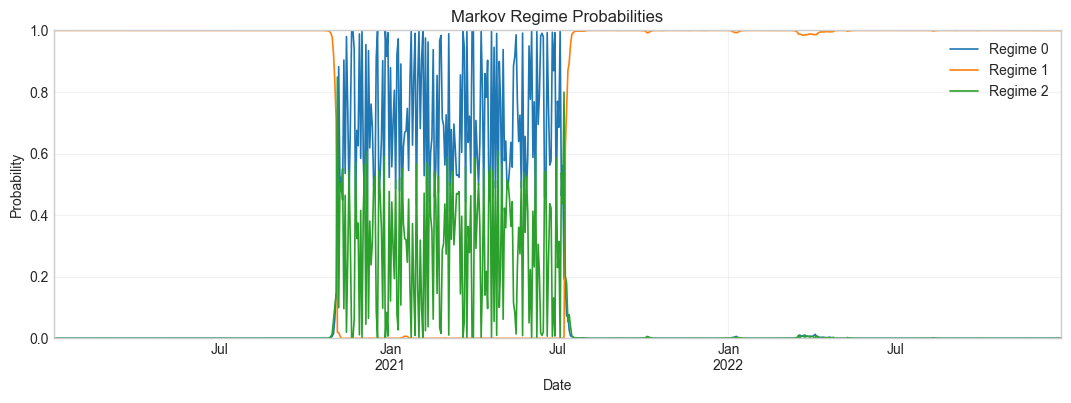

In [12]:
fig, ax = plt.subplots(figsize=(13, 4))
plot_markov_regime_probabilities(report, ax=ax)
plt.show()

## 6. Run the model on a weighted portfolio

The Markov model consumes one time series. For a multi-asset portfolio, first combine asset returns with portfolio weights, then pass the resulting portfolio return series to `build_markov_regime_report`. This keeps the regime model focused on the portfolio's realized path rather than on individual holdings.

In [14]:
asset_returns = pd.DataFrame({
    "Equity": returns + rng.normal(0.00010, 0.004, len(returns)),
    "Duration": rng.normal(0.00012, 0.006, len(returns)) - 0.25 * returns,
    "Gold": rng.normal(0.00008, 0.008, len(returns)) + 0.10 * returns,
}, index=returns.index)

weights = pd.Series({"Equity": 0.60, "Duration": 0.30, "Gold": 0.10})
portfolio_returns = asset_returns.dot(weights).rename("portfolio_returns")

portfolio_report = build_markov_regime_report(
    portfolio_returns,
    input_type="returns",
    n_regimes=3,
    random_state=42,
    n_iter=100,
)

portfolio_report.metrics["regime_summary"].round(5)

,count,mean,std,min,max
regime,,,,,
0,141,-0.00444,0.01147,-0.04054,0.02795
1,602,0.00053,0.00510,-0.01592,0.01779
2,37,0.01086,0.00408,0.00362,0.01952


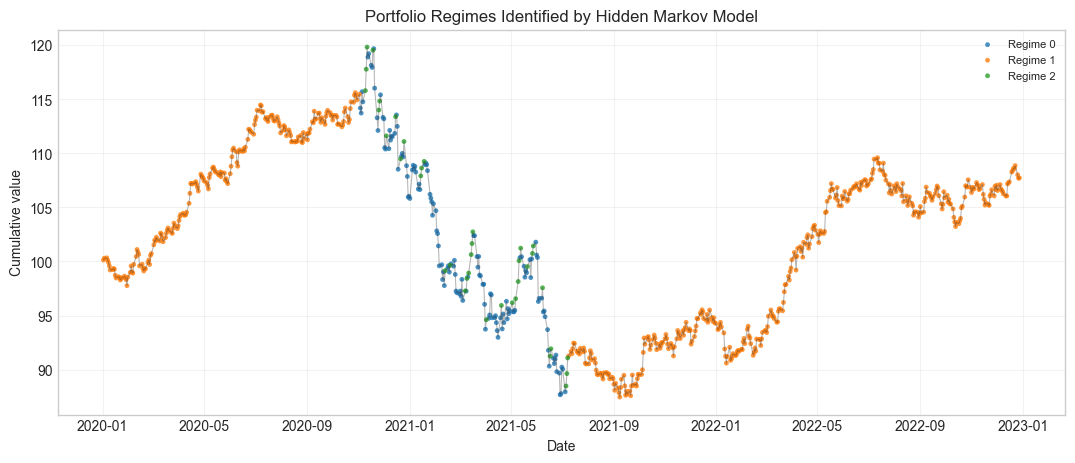

In [15]:
fig, ax = plt.subplots(figsize=(13, 5))
plot_markov_regime_chart(
    portfolio_report,
    title="Portfolio Regimes Identified by Hidden Markov Model",
    ax=ax,
)
plt.show()

## 6. How to use this in a portfolio project

A regime signal can drive monitoring, risk overlays, or strategy diagnostics. For example, you can reduce exposure in a high-volatility stress regime, compare Sharpe by regime, or annotate a market risk dashboard with the current hidden state.